In [120]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# O que você precisa fazer
É tudo com base na atividade do ava

In [121]:
#1 - Carregue o dataset
df = sns.load_dataset("penguins")

In [122]:
#2 - Faça uma análise exploratória simples
#Mostre os primeiros dados com df.head().
print("Primeiros dados:")
print(df.head())

Primeiros dados:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [123]:
#Verifique se há valores ausentes com df.isnull().sum().
print("\nValores ausentes por coluna:")
print(df.isnull().sum())


Valores ausentes por coluna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64



Espécies únicas: ['Adelie' 'Chinstrap' 'Gentoo']
Quantidade de espécies: 3


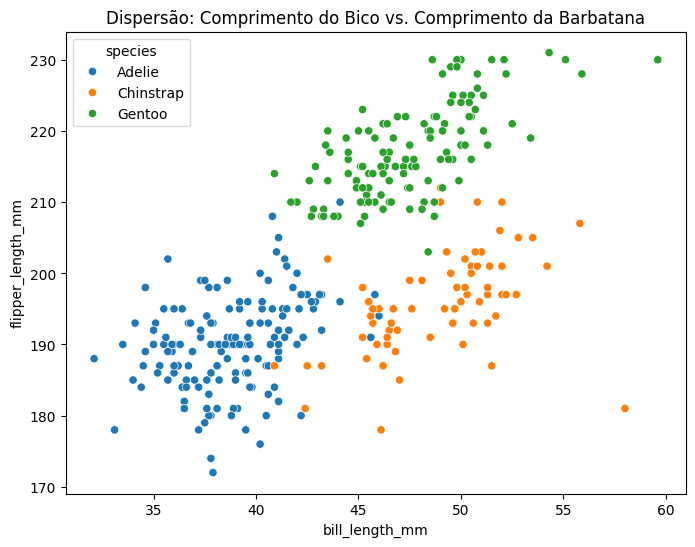

In [124]:
#Plote pelo menos um gráfico de dispersão (ex: entre comprimento do bico e da barbatana) para visualizar as espécies.
print("\nEspécies únicas:", df['species'].unique())
print("Quantidade de espécies:", df['species'].nunique())
# Gráfico de dispersão
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species')
plt.title('Dispersão: Comprimento do Bico vs. Comprimento da Barbatana')
plt.show()

In [125]:

# 3 - Prepare os dados para o modelo
#Remova ou trate os valores ausentes (por exemplo: df.dropna()).
df = df.dropna()
#Selecione as colunas numéricas como entrada (ex: comprimento do bico, profundidade do bico, comprimento da barbatana, massa corporal).
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
# Use a coluna species como variável alvo.
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [126]:
#4 - Treine um modelo de classificação
#Separe os dados em treino e teste com train_test_split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)#O random_state serve para garantir que a divisão seja sempre igual quando roda o código.
#Use o DecisionTreeClassifier ou outro modelo simples do Scikit-Learn.
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)#possui uma profundidade máxima de 4.
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
# Avalie a acurácia com accuracy_score.
acc = accuracy_score(y_test, y_pred) #Acurácia = (número de previsões corretas) ÷ (número total de previsões)
print(f"\nAcurácia do modelo: {acc:.2f}")


Acurácia do modelo: 0.98


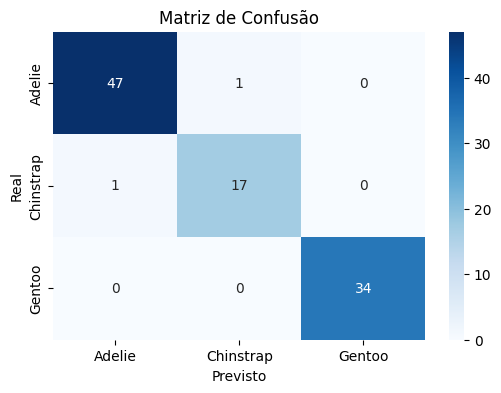

In [127]:
# Mostre a matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Responda também:
1. Qual foi a acurácia do seu modelo?<br>
**A acurácia do modelo foi de 0.98.**

2. Qual das espécies foi mais difícil de classificar corretamente?<br>
**Chinstrap.**

3. Qual variável parece mais influenciar na predição da espécie?<br>
**O max_depth ele limita a profundidade máxima da árvore.**

4. O que acontece se você remover uma das colunas do modelo?<br>
**acurácia irá aumentar de tirar o Chinstrap e cair se for os outros.**
